# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [2]:
# Importar librerías
from scipy.stats import pointbiserialr
from scipy.stats import chi2_contingency
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Cargar Dataset

In [3]:
# Cargar el dataset y explorar datos
df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [3]:
# mostrar las primeras 5 filas
df.head()

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

💡
Después de analizar la información anterior, completa la siguiente sección.  
- Si aplica, señala la o las columnas que requieren algun cambio

Recuerda eliminar este bloque de texto antes de subir el proyecto a tu portafolio.


#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
- `nivel_ingreso`
- `visitas_mes`
- `compras_mes`
- `gasto_publicidad_dirigida`
- `satisfaccion`
- `miembro_premium`
- `abandono`
- `ingreso_anual`

La mayoría de estas variables presentan tipos de datos adecuados.  
La columna `edad` esta guardad como un número con decimal, no esta mal en cuanto formato numerico, pero si para interpretación de datos, sin mencionar que si se realiza algún promedio de edad, nos dará un número con decimal, por lo cual, se registra por este medio que se hará una conversión de la columna `edad` de número decimal (float64) a número entero (int64).


**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [4]:
# Corregir el tipo de dato
df['edad'] = df['edad'].astype(int)

In [5]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [6]:
# Estadísticas descriptivas de variables numéricas
cols_numericas = ['edad','nivel_ingreso','visitas_mes','compras_mes','gasto_publicidad_dirigida','satisfaccion','ingreso_anual']
df[cols_numericas].describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,244.690000


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables numéricas

- `edad` — Tenemos un promedio de edad de 38 años, con un mínimo de 18 años, y un máximo de 75. En cuanto al mínimo de edad no hay mucho que añadir, ya que las cuentas bancarias se pueden aperturar con una mayoria de edad de 18 años en la mayoria de los paises de Latinoamerica; en cuanto a la edad máxima, podriamos añadir que tenemos un foco de atención, ¿Por qué personas mayores de 75 años no realizan compras en línea? Podría ser por desconocimiento de la tecnología, o por desconfianza en el método de compra, o dificultades en los procesos lo cual pudo haber dejado malas experiencias.
- `nivel_ingreso` — El promedio de ingreso lo vemos en 30,019.70, con mínimo de 8,000.00 y máximo de 74,790.84. (`Al ser una plataforma de e-commerce, el tipo de cambio que se debe manejar es en dolares US`)
- `visitas_mes` — Tenemos un promedio de visitas de 10, con un mínimo de 1, y un máximo de 25. Las visita máxima de 25 veces por mes no llegaría a ser extraño, ya que se tiene una variable que cataloga a los clientes en básicos o premium.
- `compras_mes` — Tenemos un promedio de una compra al mes, con mínimo de cero, y máximo de 8. Los mínimos de cero nos podrían contar una historia que sería importante analizar en su momento, hay usuarios que no están finalizando sus procesos de compra, podría ser por que los precios no son atractivos, o por que la experiencia dentro de la plataforma no es la más amigable.
- `gasto_publicidad_dirigida` — Ya que tenemos clientes con cero compras al mes, puede que se haya tomado la decisión de que no era importante tener un gasto publicitario en usuarios que no llegan a terminar los procesos de compras, se recomienda analizar la estrategía de selección de gasto en publicidad dirigida.
- `satisfaccion` — Es una dato que tiende a ser subjetivo de acuerdo a la experiencia de compra y nivel de satisfacción de lo que se adquirio, es importante saberlo para las estrategias del área comercial y de marketing.
- `ingreso_anual` — Tenemos un promedio de 36.59 al año, con un mínimo de 0.00 y un máximo de 244.69, también apreciamos un percentil 25 también de 0.00, esto nos dice que al menos el 25% de los usuarios genera 0.00 anual, es un foco de atención. Se aporta dos hipótesis: una puede ser falta de engagement, donde el usuario visito, pero no compro nada. Y otra hipótesis, que la experiencia del usuario por el dispositivo donde hizo la visita, experimento dificultades en el proceso.

#### Explorar variables binarias

In [7]:
# Verificar que cada columna tenga únicamente dos valores posibles
cols_binarias = ['miembro_premium','abandono']
df[cols_binarias].nunique()

miembro_premium    2
abandono           2
dtype: int64

In [8]:
df[cols_binarias].value_counts()

miembro_premium  abandono
0                0           10741
                 1            2170
1                0            1998
                 1              91
dtype: int64

In [9]:
(df[cols_binarias].value_counts(normalize=True) * 100).round(2)

miembro_premium  abandono
0                0           71.61
                 1           14.47
1                0           13.32
                 1            0.61
dtype: float64

In [10]:
df['miembro_premium'].value_counts()

0    12911
1     2089
Name: miembro_premium, dtype: int64

In [11]:
df['abandono'].value_counts()

0    12739
1     2261
Name: abandono, dtype: int64

In [12]:
(df['abandono'].value_counts(normalize=True) * 100).round(2)

0    84.93
1    15.07
Name: abandono, dtype: float64

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables binarias

- `miembro_premium` — se confirmo que solo se tienen dos valores posibles. Se contaron 2,089 miembros premium, y 12,911 miembros básicos.
- `abandono` — se confirmo que solo se tienen dos valores posibles. Se aprecia una tasa de abandono del 15.07% lo que representa 2,261 usuarios que no concluyeron el proceso de compra. Dentro de los segmentos, podemos observar que los usuarios premium tuvieron una tasa de abandono de 0.61% y los usurios básicos tuvieron una tasa de abanono de 14.47%

#### Explorar variables categóricas

In [13]:
# Verificar el número de valores únicos por variable categórica
cols_categoricas = ['tipo_dispositivo','region']
df[cols_categoricas].nunique()

tipo_dispositivo    3
region              4
dtype: int64

In [14]:
# Explorar variables categóricas y cómo se distribuyen
df[cols_categoricas].value_counts()

tipo_dispositivo  region
móvil             norte     2843
                  oeste     2489
                  sur       2483
                  este      2003
escritorio        norte     1125
                  oeste      935
                  sur        894
                  este       766
tablet            norte      427
                  oeste      386
                  sur        349
                  este       300
dtype: int64

In [15]:
df['tipo_dispositivo'].value_counts()

móvil         9818
escritorio    3720
tablet        1462
Name: tipo_dispositivo, dtype: int64

In [16]:
df['region'].value_counts()

norte    4395
oeste    3810
sur      3726
este     3069
Name: region, dtype: int64

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables categóricas

- `tipo_dispositivo` — Tenemos tres tipos de dispositivos registrados: móvil (9,818 usuarios), escritorio (3,720 usuarios), tablet (1,462 usuarios)
- `region` — Tenemos cuatro regiones: norte (4,395 usuarios), oeste (3,810 usuarios), sur (3,726 usuarios), este (3,069 usuarios).
- Dentro de las regiones tenemos que:

- En el norte: hay 2843 en móvil, 1125 en escritorio, 427 en tablet.
- En el oeste: hay 2489 en móvil,  935 en escritorio, 386 en tablet.
- En el sur:   hay 2483 en móvil,  894 en escritorio, 349 en tablet.
- En el este:  hay 2003 en móvil,  766 en escritorio, 300 en tablet.

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

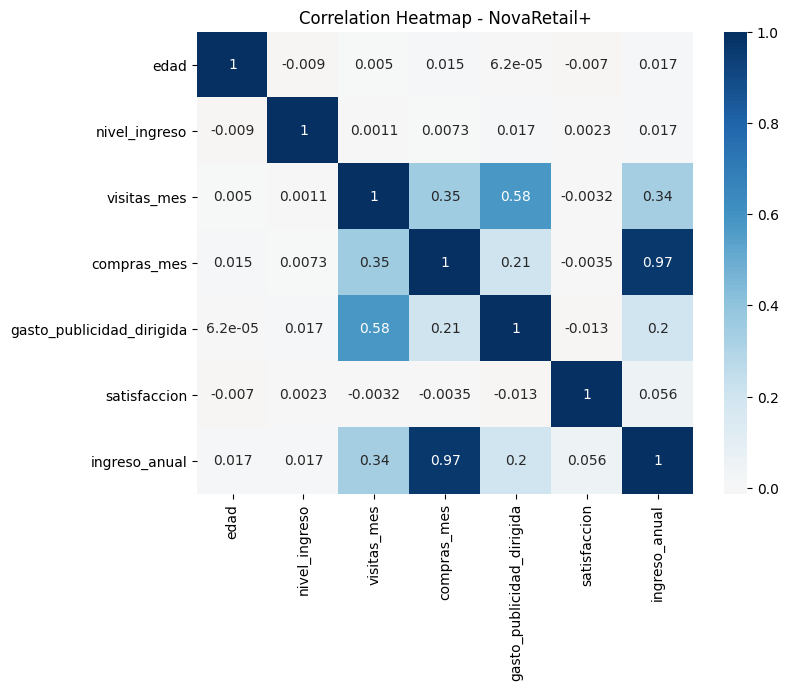

In [17]:
# Visualizar la matriz de correlación para identificar relaciones
corr = df[cols_numericas].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="RdBu", center=0)
plt.title("Correlation Heatmap - NovaRetail+")
plt.show()

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves


Observaciones generales (Heatmap)  
- Se observa las variables tienen correlaciones casi nulas, lo cual nos podría decir en un primer analisis que no hay influencia de una con la otra, para confirmar habría que hacer un analisis más profundo o segmentado.

- Hay variables que si nos muestran correlaciones moderadas o debiles:

Tenemos el caso de `visitas_mes` con `gasto_publicidad_dirigida` con una correlación moderada de 0.58, lo cual nos indica que en cuanto más sea el gasto en publicidad dirigida, se aprecian mas visitas al mes, sería ideal someter esta información a un análisis segmentado, para evaluar como se derarrollan los clientes premium de los básicos.

En concordancia, tenemos la correlación de `visitas_mes` con `compras_mes`, con una correlación leve de 0.35, lo que nos indica que más compras en el mes pueden acompañarse de más ventas en el mes.

Observaciones respecto a `ingreso_anual`  
- Presenta una correlación muy alta de 0.97 con `compras_mes` al ser un número cercano al uno, se puede llegar a deducir que a mayor compras al mes, hay mayor ingreso anual, ahi el razón de la correlación.
- Tenemos una correlación moderada de 0.34 con `visitas_mes`, lo que nos indica que los usurios que visitan más la tienda, tienden a concentrar más ingreso anual.
- Tenemos otra correlación leve de 0.20 con `gasto_publicidad_dirigida`, lo que nos podría llegar a indicar que donde se concentra el gasto en publicidad hay más ingreso anual.


### Scatterplot general

Con base en los resultados del análisis de correlación, evalúa si es necesario generar un *scatterplot* general.

- **Si decides incluirlo**:
  - Genera el gráfico.
  - Describe brevemente qué patrones o tendencias observas.

- **Si decides no incluirlo**:
  - Explica por qué.

- Se decidio no incluir el scatterplot general por que hay muchas relaciones débiles o irrlevantes, y ya que el objetivo del análisis es evaluar los ingresos anuales, es más eficiente concentrar la atención en las variables que nos muestren una correlación más sobresaliente, y generar los gráficos

### Scatterplot para pares clave

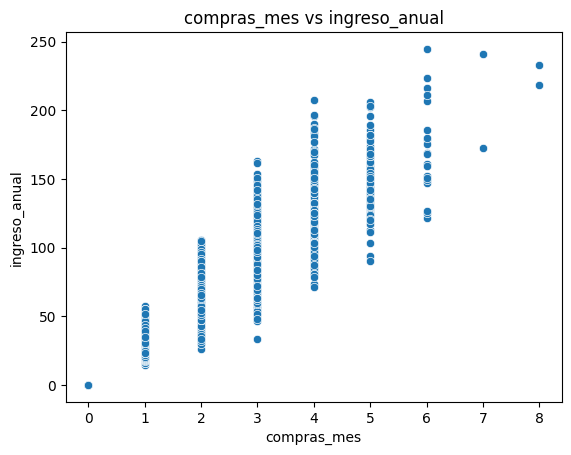

In [18]:
# Visualizar pares de variables con relaciones moderadas o fuertes
sns.scatterplot(data=df, x='compras_mes', y='ingreso_anual')
plt.title("compras_mes vs ingreso_anual")
plt.show()

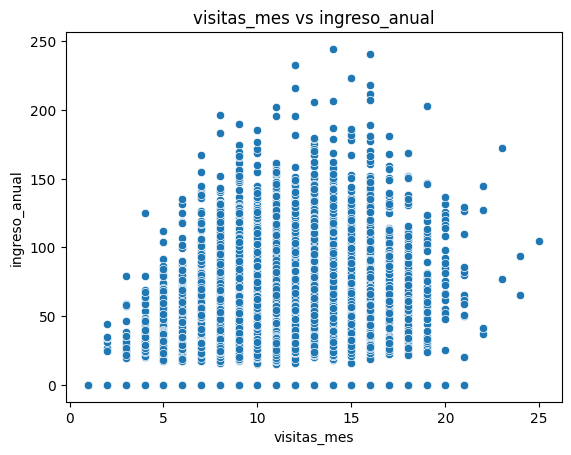

In [19]:
sns.scatterplot(data=df, x='visitas_mes', y='ingreso_anual')
plt.title("visitas_mes vs ingreso_anual")
plt.show()

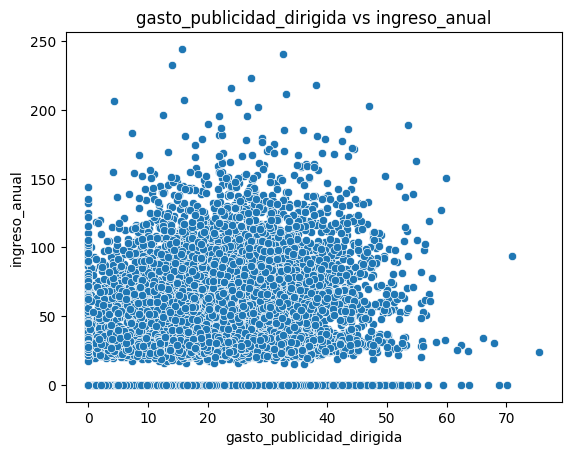

In [20]:
sns.scatterplot(data=df, x='gasto_publicidad_dirigida', y='ingreso_anual')
plt.title("gasto_publicidad_dirigida vs ingreso_anual")
plt.show()

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves: dirección (positiva o negativa), dispersión (alta, media, baja), presencia de outliers y posible colinealidad.


Observaciones iniciales (Scatterplot)

**`ingreso_anual` vs `compras_mes`**
- Dirección tenemos una relación `positiva`: a más `compras_mes` tenemos mayor tendencia en `ingreso_anual`.
- Dispersión es alta vertical en cada columna, lo que nos indica que `compras_mes` no explica completamente el `ingreso_anual`, ya que dos clientes con el mismo número de compras al mes, pueden generar distintos ingresos anuales.
- Forma es una relación lineal, pero se aprecia mucho ruido en cada columna. Esto relacionado con la explicación la dispersión, cada usuario tiene una interacción distinta y costumbres de compra distintas, lo que nos genera que haya mucho valores en una sola columna. Por lo que hay otras variables que también influyen en el ingreso. Esta variable por si sola, no es suficiente para predecir el `ingreso_anual` por usuario.

**`ingreso_anual` vs `visitas_mes`**
- Dirección tenemos una relación `positiva`, aunque más débil que `compras_mes`.
- Dispersión es alta, y con muchos datos concentrados en la parte baja del eje Y.
- Forma, es lineal, con columnas verticales por ser datos enteros. La conclusión es similar a la del scatterplot anterior. No es una variable que por si sola nos pueda dar un panorama del origen de los ingresos anuales, por lo que es recomendable realizar otro tipo de análisis para llegar a una conclusión más adecuada.

**`ingreso_anual` vs `gasto_publicidad_dirigida`**
- Dirección tenemos una relación `débil` en donde no se observa una tendencia clara de subida o bajada a medida que aumenta el `gasto_publicidad_dirigida`. Hay puntos que se distribuyen de manera muy horizontal a lo largo del eje X.
- Dispersión es muy alta, donde se aprecia que están muy esparcidos en el eje X, y tenemos dos zonas diferenciadas: una línea que se extiende de forma horizontal con valor a cero en el eje X, y una nube densa entre 20-150 que concentra la mayoría de los datos.
- Forma, no se puede apreciar una forma lineal ni curvilínea clara, ya que la nube de puntos no parece seguir ningún patrón definido. Esto nos refuerza la conclusión de que es una relación débil. Sobre los datos en cero que se perciben en el gráfico, se recomienda que se conserven, ya que pueden contar una historia importante acerca de la designación del presupuesto de `gasto_publicidad_dirigida` y en que perfiles de usuarios.

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [21]:
# Calcular correlación entre variables relevantes
cols_relevantes = ['compras_mes','visitas_mes','gasto_publicidad_dirigida','ingreso_anual']

pearson = df[cols_relevantes].corr(method='pearson')
pearson

,compras_mes,visitas_mes,gasto_publicidad_dirigida,ingreso_anual
compras_mes,1.000000,0.353844,0.207528,0.967149
visitas_mes,0.353844,1.000000,0.578947,0.337147
gasto_publicidad_dirigida,0.207528,0.578947,1.000000,0.197483
ingreso_anual,0.967149,0.337147,0.197483,1.000000


In [22]:
# Calcular correlación entre variables relevantes
spearman = df[cols_relevantes].corr(method='spearman')
spearman

,compras_mes,visitas_mes,gasto_publicidad_dirigida,ingreso_anual
compras_mes,1.000000,0.332943,0.192511,0.967482
visitas_mes,0.332943,1.000000,0.559267,0.320954
gasto_publicidad_dirigida,0.192511,0.559267,1.000000,0.184999
ingreso_anual,0.967482,0.320954,0.184999,1.000000


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves: dirección, magnitud y posible colinealidad.


Observaciones de correlación

**`ingreso_anual` vs `compras_mes`**
- Dirección: Correlación positiva  muy alta, se observa que los clientes con más compras al mes tienden a asociarse con mayor ingreso anual.
- Magnitud: 0.967 (Pearson) / 0.967 (Spearman).
- Colinealidad: no existe, solo tenemos una correlación fuerte entre nuestra variable predictora (compras_mes) y nuestra variable objetivo (ingreso_anual).

**`visitas_mes` vs `gasto_publicidad_dirigida`**
- Dirección: Correlación positiva moderada, se observa que los clientes con mayor gasto en publicidad dirigida tienden a registrar más visitas al mes, lo que motiva un análisis más profundo entre ambas para entender si hay factores intermedios.
- Magnitud: 0.578 (Pearson) / 0.559 (Spearman)
- Colinealidad: Se observó una correlación positiva moderada entre visitas_mes y gasto_publicidad_dirigida, lo que sugiere una posible colinealidad. Esto indica que ambas variables podrían estar capturando información similar, lo cual podría afectar la estabilidad del modelo si se usan juntas como predictores, por lo que se recomienda aplicar otros métodos y analizar si se eliminan variables o se combinan variables.

### Punto-biserial

In [23]:
# Calcular correlación entre variables relevantes
for col in cols_binarias:
    corr, pval = pointbiserialr(df['ingreso_anual'],df[col])
    print(f"Variable: {col} | Correlación: {corr}")

Variable: miembro_premium | Correlación: 0.0930994396198015
Variable: abandono | Correlación: -0.002823934021617148


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves: dirección (positiva o negativa), magnitud (alta, media, baja).

Observaciones Punto-biserial

**`ingreso_anual` vs `miembro_premium`**
- Relación positiva baja,
- Magnitud baja, de 0.093.
- Aunque la relación es positiva baja, tiene algo de correlación, pero es tan debil que por si sola no es suficiente para tomar desiciones de negocio importantes.

**`ingreso_anual` vs `abandono`**
- Relación negativa baja.
- Magnitud baja negativa, de -0.0028, practicamente cero.
- Al tener un valor cercano a cero, se puede concluir que no es útil para el análisis del negocio. La variable no puede aportar para predecir o explicar la otra variable, en este caso, ingreso anual.

### V de Cramér

In [24]:
# Función para calcular V de Cramér
tabla = pd.crosstab(df['tipo_dispositivo'],df['region'])
tabla

region,este,norte,oeste,sur
tipo_dispositivo,,,,
escritorio,766,1125,935,894
móvil,2003,2843,2489,2483
tablet,300,427,386,349


In [25]:
# Aplicar V de Cramér en variables relevantes
chi2, p, dof, expected = chi2_contingency(tabla)
chi2

4.596697852095489

In [26]:
n = tabla.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(tabla.shape) -1)))
cramers_v

0.012378338407739397

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.
Incluye qué ves


**Observaciones V de Cramér:**

- Asociación: Visualizamos asociación entre las variables región y tipo de dispositivo, aunque es muy débil.
- Magnitud: con un valor de 0.0124, la fuerza de asociación es débil.
- Implicación de negocio: el tipo de dispositivo que usan los usuarios no tiene una variación significativa entre las regiones, aunque vemos un mayor uso de los dispositivos móviles, se tienen que evaluar otras variantes antes de proponer acciones y enfoques de campañas. No hay patrón claro entre categorías.


## Sección 5 - Interpretación de resultados para el negocio

Cada hallazgo  debe incluir:
1) Evidencia visual (si aplica)
2) Evidencia numérica  
3) Interpretación (no causal)  
4) No podemos afirmar
5) Implicación de negocio

---

✍️ **Hallazgos**: Completa los siguientes bloques.   
Si lo crees necesario, puedes agregar mas hallazgos.  

Recuerda eliminar este bloque de texto antes de incluir el proyecto en tu portafolio.

### Hallazgo 1 — `ingreso_anual` vs `compras_mes`

**Evidencia visual:**
De acuerdo al heatmap apreciamos una correlación de 0.97, , con un color azul intenso, es muy cercana a 1, lo que significa que la relación entre esas dos variables es casi perfectamente lineal y positiva. De acuerdo al scatterplot, la dirección de la relación aumenta. La forma de los puntos siguen una línea recta. La dispersión representa muchos puntos separados en cada columna, ya que cada usuario aporta un valor distinto en cada una de estas columnas, lo que genera variaciones en los montos percibidos en el ingreso anual.

**Evidencia numérica:** 
Se muestra una correlación de: 0.967 (Pearson) / 0.967 (Spearman). Son relaciones positivas con una correlación alta. Si la correlación de Pearson y Spearman coinciden tanto, nos indica que los datos son lineales, no tenemos outliers que distorsionen el análisis.

**Interpretación**  
Los clientes que más compras al mes realizan tienden a aportar más en el ingreso anual. Esto lo podemos apreciar con la correlación de Pearson de 0.967; con la correlación de Spearman tambien tenemos un dato de 0.967, lo que que nos confirma de acuerdo a la escala de valores absolutos que es una correlación muy fuerte.

**No podemos afirmar**  
Que intentar incentivar el aumento de las compras por parte de los usuarios incrementará el ingreso anual. Se deberán realizar otro tipo de consideraciones para determinar que otros factores contribuyen al aumento del ingreso anual.

**Implicación de negocio**  
Los clientes con mayor frecuencia de compra y mayor volumen de compra, representan un segmento de alto valor para el ingreso anual, por lo que retenerlos podría ser prioritario.


### Hallazgo 2 — `ingreso_anual` vs `visitas_mes`

**Evidencia visual:**   
De acuerdo al heatmap apreciamos una correlación de 0.34, con un color azul medio intenso, lo que significa que la relación entre esas dos variables es debíl, es lineal y positiva. De acuerdo al scatterplot, la dirección de la relación aumenta. La dispersión es más visible en el scatterplot, representada por muchos puntos separados en cada columna, cada usuario aporta un valor distinto en cada una de estas columnas al igual que en compras al mes, cada usuario genera distintas visitas al mes.

**Evidencia numérica:** 
Se muestra una correlación de: 0.353 (Pearson) / 0.332 (Spearman). Son relaciones positivas con una correlación débil. Si la correlación de Pearson es mayor que la de Spearman, nos indica que los datos son lineales, y tenemos una relación lineal en el análisis.

**Interpretación**  
Los clientes que más visitas realizan al mes tienden a aportar más en el ingreso anual. Esto lo podemos apreciar con la correlación de Pearson de 0.353; con la correlación de Spearman tambien tenemos un dato de 0.332, lo que que nos confirma de acuerdo a la escala de valores absolutos que es una correlación debíl.

**No podemos afirmar**  
Que intentar aumentar las visitas de los usuarios incrementará el ingreso anual. Se deberán realizar otro tipo de consideraciones para determinar que otros factores contribuyen a la decisión de compras y al aumento del ingreso anual.

**Implicación de negocio**  
Los clientes con más visitas al mes, representan un segmento importante para el ingreso anual, por lo que evaluar los motivos de visitas al mes podría ser prioritario para el negocio y puede traer nuevos datos sobre la mesa.


### Hallazgo 3 — `visitas_mes` vs `gasto_publicidad_dirigida`

**Evidencia visual:**
De acuerdo al heatmap apreciamos una correlación de 0.58, con un color azul medio, lo que significa que la relación entre esas dos variables es moderada (casí fuerte), es lineal y positiva. De acuerdo al scatterplot, a medida que aumenta el gasto en publicidad dirigida, también tienden a aumentar las visitas al mes. Vemos una dispersión visible en el scatterplot, representada por muchos puntos separados en cada columna.

**Evidencia numérica:** 
Se muestra una correlación de: 0.578 (Pearson) / 0.559 (Spearman). Son relaciones positivas con una correlación moderada. Si la correlación de Pearson es mayor que la de Spearman, nos indica que los datos son lineales, y tenemos una relación lineal en el análisis.

**Interpretación**  
Los clientes que más gasto en publicidad dirigida reciben tienden a realizar mas visitas al mes. Esto lo podemos apreciar con la correlación de Pearson de 0.578; con la correlación de Spearman tambien tenemos un dato de 0.559, lo que que nos confirma de acuerdo a la escala de valores absolutos que es una correlación moderada, casi fuerte. 

**No podemos afirmar**  
Que si hay un mayor gasto en gasto en publicidad dirigida, tendremos un mayor tráfico de visitas al mes. Se tienen que analizar variables adicionales para llegar a una conclusión más sólida.

**Implicación de negocio**  
Evaluar a que tipos de cliente se les asigna presupuesto de gasto de publicidad dirigida, y revisar cuantas compras al mes se realizaron para clientes que recibieron gasto de publicidad dirigida. Para qué el marketing pueda maximizar el retorno del gasto publicitario.


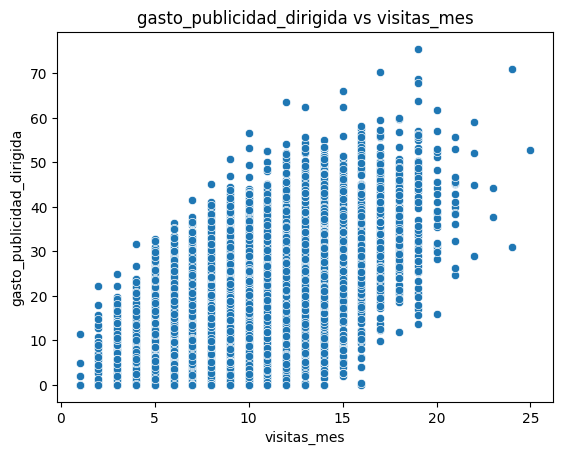

In [6]:
sns.scatterplot(data=df, x='visitas_mes', y='gasto_publicidad_dirigida')
plt.title("gasto_publicidad_dirigida vs visitas_mes")
plt.show()

## Sección 6 - Limitaciones y próximos pasos

✍️ **Comentario**: Completa el siguiente bloque.   
Modifica según creas necesario.  

Recuerda eliminar este bloque de texto antes de incluir el proyecto en tu portafolio.

### **Limitaciones**
- Correlación ≠ causalidad. A pesar de que visualizamos una correlación muy fuerte entre `compras_mes` y `ingreso_anual`, el hecho que el valor de correlación sea tan alto es un foco de atención a revisar, ya que no es normal tener correlaciones tan altas. Sería importante sumar al analisis otro tipo de variables importantes, para entregar un análisis más acertado. 
- Se observa una correlación positiva moderada entre `visitas_mes` y `gasto_publicidad_dirigida`, lo que sugiere una posible colinealidad. Posiblemente ambas variables podrían estar capturando información similar, lo cual podría afectar la estabilidad del modelo si se usan juntas como predictores, por lo que se recomienda aplicar otros métodos y analizar si se eliminan variables o se combinan variables.

### **Próximos pasos** 

*Paso 1* *Probar segmentación adicional:* 
- En `compras_mes` para analizar que tipo de usuarios aportan el mayor volumen de compras al mes.
- En `gasto_publicidad_dirigida` para analizar el comportamiento de los usuarios con anuncios de publicidad dirigida.

*Paso 2*
- Analizar el volumen de compras de los usuarios que reciben anuncios con publicidad dirigida por region y por dispositivo.

*Paso 3*
- Analizar el funnel de NovaRetail, para conocer tasa de abandono en las fases y formular recomendaciones con base en la información recabada.